# Exploratory Data Analysis（探索的データ分析）

## 目的
求人充足率低下の要因分析に向けて、求人・応募データの分布、欠損、年次差を確認する。
本Notebookでは、SQLで作成した分析マートをPythonに読み込み、データの品質や分布を確認したうえで、2025年と2026年の傾向を比較する。
この段階では仮説の統計的な有意性を判断するのではなく、合成データが分析可能な状態になっているか、また想定した方向性がデータに表れているかを探索的に確認する。

## 主な確認項目
- 60日以内募集枠充足率
- 給与ギャップ
- スキルギャップ
- 選考リードタイム
- 就業決定率

## 使用する分析マート
- `mart_job_analysis`
  - 1行 = 1求人
  - 求人属性、応募ファネル、就業決定数、60日以内募集枠充足率などを保持

- `mart_application_analysis`
  - 1行 = 1応募案件
  - 給与ギャップ、スキルギャップ、選考リードタイム、辞退・就業決定などを保持

## 1. ライブラリの読み込み
分析に必要なPythonライブラリを読み込む。

- `sqlite3`：SQLiteデータベースへ接続する
- `pandas`：表形式データをDataFrameとして扱う
- `numpy`：数値計算を行う
- `matplotlib`：グラフを作成する

In [43]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. SQLiteデータベースへの接続
Pythonから、合成データおよびSQL分析マートを格納したSQLiteデータベースへ接続する。

Notebookは `notebooks/` フォルダに保存しているため、1階層上の `database/` フォルダを参照する。

In [44]:
conn = sqlite3.connect(
    "../database/recruitment_analytics.sqlite"
)

### 接続先データベースの確認
想定したSQLiteファイルへ接続できていることを確認する。

In [46]:
pd.read_sql_query(
    "PRAGMA database_list;",
    conn
)

,seq,name,file
0,0,main,c:\Users\tomoe\OneDrive\PERSOL\キャリアスカウト\recrui...


## 3. 分析マートの読み込み
SQLで作成した2つの分析マートを、pandasのDataFrameとしてPythonへ読み込む。

- `job_df`：求人単位の分析データ
- `application_df`：応募案件単位の分析データ

SQLでデータの結合・集計を行い、Pythonではその結果を使って探索的データ分析を行う。

In [48]:
job_df = pd.read_sql_query(
    """
    SELECT *
    FROM mart_job_analysis
    """,
    conn
)

application_df = pd.read_sql_query(
    """
    SELECT *
    FROM mart_application_analysis
    """,
    conn
)

## 4. データ件数と内容の確認
読み込んだDataFrameについて、行数・列数と先頭データを確認する。

ここでは、SQLiteから想定したデータを正常に読み込めていることを確認する。

In [49]:
print("job_df:", job_df.shape)
print("application_df:", application_df.shape)

job_df: (20, 31)
application_df: (28, 55)


### 求人マートの先頭行

In [50]:
job_df.head()

,job_id,client_id,ra_id,open_date,open_year,open_month,occupation_id,occupation_name,occupation_group,location_id,...,withdrawal_count,visit_count,completed_visit_count,cancelled_visit_count,placement_count,placement_60d_count,fill_rate_60d,avg_intent_to_recommend_days,avg_recommend_to_schedule_days,avg_intent_to_decision_days
0,JOB00001,CLI067,RA002,2025-08-28,2025,2025-08,OCC003,コールセンター,カスタマーサポート,LOC008,...,0,0,0,0,0,0,0.0,NaN,NaN,NaN
1,JOB00002,CLI026,RA006,2025-08-03,2025,2025-08,OCC005,品質管理（QC）,医薬専門職,LOC008,...,0,0,0,0,0,0,0.0,NaN,NaN,NaN
2,JOB00003,CLI042,RA001,2025-07-18,2025,2025-07,OCC008,CRA,医薬専門職,LOC002,...,1,0,0,0,0,0,0.0,NaN,NaN,NaN
3,JOB00004,CLI080,RA009,2025-07-09,2025,2025-07,OCC002,データ入力,事務,LOC001,...,0,0,0,0,0,0,0.0,NaN,NaN,NaN
4,JOB00005,CLI066,RA004,2025-06-03,2025,2025-06,OCC006,DM（データマネジメント）,医薬専門職,LOC002,...,0,0,0,0,0,0,0.0,3.0,NaN,NaN


In [51]:
application_df.head()

,application_id,job_id,candidate_id,ca_id,application_source,source_entry_id,source_introduction_id,intent_confirmed_date,recommendation_date,recommendation_result,...,visit_continue_flag,recommend_to_schedule_days,schedule_to_visit_days,placed_flag,decision_date,start_date,agreed_hourly_wage,intent_to_decision_days,open_to_decision_days,placed_within_60d_flag
0,APP00001,JOB00003,CAN00006,CA010,ca_introduction,NaN,INT00021,2026-01-07,NaN,NaN,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
1,APP00002,JOB00005,CAN00006,CA010,ca_introduction,NaN,INT00020,2026-01-08,2026-01-11,rejected,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
2,APP00003,JOB00020,CAN00001,CA020,self_entry,ENT00005,NaN,2026-05-02,NaN,NaN,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
3,APP00004,JOB00020,CAN00010,CA016,self_entry,ENT00029,NaN,2026-05-02,2026-05-09,accepted,...,1,2.0,5.0,0,NaN,NaN,NaN,NaN,NaN,0
4,APP00005,JOB00010,CAN00008,CA005,ca_introduction,NaN,INT00027,2026-05-08,2026-05-11,accepted,...,1,5.0,6.0,0,NaN,NaN,NaN,NaN,NaN,0


## 5. データ型の確認
各列のデータ型と非欠損件数を確認する。
数値として分析したい列が数値型になっているか、想定外の欠損が大量に発生していないかを確認する。

### 求人マート

In [70]:
job_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   job_id                          20 non-null     str    
 1   client_id                       20 non-null     str    
 2   ra_id                           20 non-null     str    
 3   open_date                       20 non-null     str    
 4   open_year                       20 non-null     str    
 5   open_month                      20 non-null     str    
 6   occupation_id                   20 non-null     str    
 7   occupation_name                 20 non-null     str    
 8   occupation_group                20 non-null     str    
 9   location_id                     20 non-null     str    
 10  prefecture_name                 20 non-null     str    
 11  area_group                      20 non-null     str    
 12  required_slots                  20 non-null     i

### 応募案件マート

In [71]:
application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   application_id                28 non-null     str    
 1   job_id                        28 non-null     str    
 2   candidate_id                  28 non-null     str    
 3   ca_id                         28 non-null     str    
 4   application_source            28 non-null     str    
 5   source_entry_id               20 non-null     str    
 6   source_introduction_id        8 non-null      str    
 7   intent_confirmed_date         28 non-null     str    
 8   recommendation_date           13 non-null     str    
 9   recommendation_result         13 non-null     str    
 10  withdrawal_date               4 non-null      str    
 11  withdrawal_reason             4 non-null      str    
 12  application_status            28 non-null     str    
 13  application_year  

## 6. 欠損値の確認
列ごとの欠損値件数を確認する。
欠損が存在すること自体を異常とは判断しない。

例えば、推薦に進んでいない応募案件では `recommendation_date`、辞退していない案件では `withdrawal_date`、就業決定していない案件では `decision_date` がNULLになることは業務上自然である。

ここでは、想定していない列に欠損が発生していないかを確認する。

### 求人マート

In [72]:
job_df.isna().sum()

job_id                             0
client_id                          0
ra_id                              0
open_date                          0
open_year                          0
open_month                         0
occupation_id                      0
occupation_name                    0
occupation_group                   0
location_id                        0
prefecture_name                    0
area_group                         0
required_slots                     0
offered_hourly_wage                0
required_skill_level               0
work_style                         0
entry_count                        0
converted_entry_count              0
application_count                  0
recommendation_count               0
recommendation_accepted_count      0
withdrawal_count                   0
visit_count                        0
completed_visit_count              0
cancelled_visit_count              0
placement_count                    0
placement_60d_count                0
f

### 応募案件マート

In [73]:
application_df.isna().sum()

application_id                   0
job_id                           0
candidate_id                     0
ca_id                            0
application_source               0
source_entry_id                  8
source_introduction_id          20
intent_confirmed_date            0
recommendation_date             15
recommendation_result           15
withdrawal_date                 24
withdrawal_reason               24
application_status               0
application_year                 0
application_month                0
open_date                        0
client_id                        0
ra_id                            0
occupation_id                    0
occupation_name                  0
occupation_group                 0
location_id                      0
required_slots                   0
offered_hourly_wage              0
required_skill_level             0
work_style                       0
preferred_occupation_id          0
preferred_location_id            0
desired_hourly_wage 

## 7. 数値項目の基本統計量
主要な数値項目について、件数・平均・標準偏差・最小値・四分位数・最大値を確認する。

極端な値や業務上不自然な値が含まれていないかを確認する。

### 求人マートの主要数値項目

In [56]:
job_df[
    [
        "required_slots",
        "offered_hourly_wage",
        "required_skill_level",
        "entry_count",
        "application_count",
        "placement_count",
        "fill_rate_60d",
    ]
].describe()

,required_slots,offered_hourly_wage,required_skill_level,entry_count,application_count,placement_count,fill_rate_60d
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000
mean,1.400000,2107.500000,2.900000,1.450000,1.400000,0.150000,0.07500
std,0.598243,647.317339,1.333772,1.986136,1.429022,0.366348,0.24468
min,1.000000,1200.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,1512.500000,1.750000,0.000000,1.000000,0.000000,0.00000
50%,1.000000,2100.000000,3.000000,0.500000,1.000000,0.000000,0.00000
75%,2.000000,2275.000000,4.000000,2.000000,1.000000,0.000000,0.00000
max,3.000000,3300.000000,5.000000,6.000000,5.000000,1.000000,1.00000


### 応募案件マートの主要数値項目

In [57]:
application_df[
    [
        "wage_gap",
        "wage_gap_rate",
        "skill_gap",
        "intent_to_recommend_days",
        "recommend_to_schedule_days",
        "schedule_to_visit_days",
        "intent_to_decision_days",
        "withdrawal_flag",
        "placed_flag",
    ]
].describe()

,wage_gap,wage_gap_rate,skill_gap,intent_to_recommend_days,recommend_to_schedule_days,schedule_to_visit_days,intent_to_decision_days,withdrawal_flag,placed_flag
count,28.000000,28.000000,10.000000,13.000000,8.000000,7.000000,3.0,28.000000,28.000000
mean,319.642857,0.235964,0.000000,3.076923,3.125000,5.285714,13.0,0.142857,0.107143
std,814.718684,0.429861,0.471405,1.891276,1.125992,1.889822,1.0,0.356348,0.314970
min,-1600.000000,-0.451000,-1.000000,1.000000,2.000000,3.000000,12.0,0.000000,0.000000
25%,-87.500000,-0.047250,0.000000,2.000000,2.000000,4.000000,12.5,0.000000,0.000000
50%,200.000000,0.076500,0.000000,3.000000,3.000000,5.000000,13.0,0.000000,0.000000
75%,825.000000,0.482000,0.000000,3.000000,4.000000,6.500000,13.5,0.000000,0.000000
max,1850.000000,1.276000,1.000000,7.000000,5.000000,8.000000,14.0,1.000000,1.000000


## 8. カテゴリ項目の分布確認
職種、勤務形態、応募経路、応募案件ステータスなどについて、カテゴリ別件数を確認する。

特定カテゴリへデータが極端に偏っていないか、想定外のカテゴリ値が存在しないかを確認する。

### 職種別求人件数

In [58]:
job_df["occupation_name"].value_counts()

occupation_name
DM（データマネジメント）    5
品質管理（QC）         3
一般事務             3
統計解析             3
データ入力            2
CRC              2
コールセンター          1
CRA              1
Name: count, dtype: int64

### 勤務形態別求人件数

In [59]:
job_df["work_style"].value_counts()

work_style
onsite    10
hybrid     6
remote     4
Name: count, dtype: int64

### 応募経路別件数

In [60]:
application_df["application_source"].value_counts()

application_source
self_entry         20
ca_introduction     8
Name: count, dtype: int64

### 応募案件ステータス別件数

In [61]:
application_df["application_status"].value_counts()

application_status
confirmed      11
rejected        5
recommended     5
withdrawn       4
placed          3
Name: count, dtype: int64

## 9. 2025年・2026年の年次比較
求人公開年および応募年ごとに主要指標を集計し、2025年と2026年の方向性を確認する。

小規模テストデータのため、この段階では統計的な有意差を判断しない。

目的は、合成データ生成時に設定した仮説の方向性が分析データにも表れているかを探索的に確認することである。

### 求人単位の年次集計
求人件数、募集枠数、エントリー数、応募数、60日以内就業決定数を年別に集計する。

60日以内募集枠充足率は、
`60日以内就業決定数 ÷ 募集枠数`
として算出する。

In [74]:
job_year_summary = (
    job_df
    .groupby("open_year")
    .agg(
        job_count=("job_id", "count"),
        total_slots=("required_slots", "sum"),
        total_entries=("entry_count", "sum"),
        total_applications=("application_count", "sum"),
        placements_60d=("placement_60d_count", "sum"),
    )
)

job_year_summary["fill_rate_60d"] = (
    job_year_summary["placements_60d"]
    / job_year_summary["total_slots"]
)

job_year_summary

,job_count,total_slots,total_entries,total_applications,placements_60d,fill_rate_60d
open_year,,,,,,
2025,10,13,0,6,0,0.000000
2026,10,15,29,22,2,0.133333


### 応募案件単位の年次集計
応募件数、給与ギャップ、スキルギャップ、推薦までの日数、辞退率、就業決定率を年別に集計する。

`withdrawal_flag` と `placed_flag` は、該当する場合を1、該当しない場合を0としているため、平均値を計算することで比率を求められる。

In [63]:
application_year_summary = (
    application_df
    .groupby("application_year")
    .agg(
        application_count=(
            "application_id",
            "count"
        ),
        avg_wage_gap_rate=(
            "wage_gap_rate",
            "mean"
        ),
        avg_skill_gap=(
            "skill_gap",
            "mean"
        ),
        avg_intent_to_recommend_days=(
            "intent_to_recommend_days",
            "mean"
        ),
        avg_intent_to_decision_days=(
            "intent_to_decision_days",
            "mean"
        ),
        withdrawal_rate=(
            "withdrawal_flag",
            "mean"
        ),
        placement_rate=(
            "placed_flag",
            "mean"
        ),
    )
)

application_year_summary

,application_count,avg_wage_gap_rate,avg_skill_gap,avg_intent_to_recommend_days,avg_intent_to_decision_days,withdrawal_rate,placement_rate
application_year,,,,,,,
2026,28,0.235964,0.0,3.076923,13.0,0.142857,0.107143


## 10. 60日以内募集枠充足率の年次比較
今回の主要KPIである60日以内募集枠充足率を、2025年と2026年で比較する。

このグラフでは、2026年に充足率が低下する方向性が表れているかを確認する。

ただし、現在は小規模なテストデータであるため、差の大きさそのものを分析結果とは判断しない。

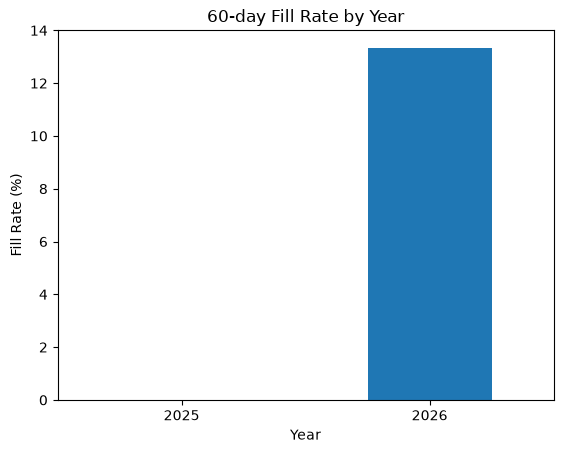

In [64]:
fill_rate_plot = (
    job_year_summary["fill_rate_60d"]
    * 100
)

fill_rate_plot.plot(
    kind="bar"
)

plt.title(
    "60-day Fill Rate by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Fill Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.show()

### 10.1 充足率の年次差に関する追加確認
60日以内募集枠充足率を確認したところ、2025年が0%、2026年が約13%となり、想定していた「2026年に充足率が低下する」という方向性とは逆の結果となった。

この結果が実際の要因差によるものか、小規模テストデータの生成条件によるものかを切り分けるため、以下を追加確認する。

- 候補者登録年の分布
- 候補者の具体的な登録日
- 年別・応募経路別の応募案件数
- 求人公開日と応募意思確認日の関係

#### 候補者登録年の確認
候補者数が2025年・2026年のどちらかに偏っていないか確認する。

In [75]:
candidate_df = pd.read_sql_query(
    """
    SELECT *
    FROM candidates
    """,
    conn
)

candidate_df["registration_date"] = pd.to_datetime(
    candidate_df["registration_date"]
)

candidate_df["registration_year"] = (
    candidate_df["registration_date"].dt.year
)

candidate_df[
    "registration_year"
].value_counts().sort_index()

registration_year
2025    5
2026    5
Name: count, dtype: int64

#### 候補者登録日の確認
年単位ではなく、2025年4〜9月の求人公開期間に実際に何名の候補者が登録済みだったか確認する。

In [76]:
candidate_df[
    [
        "candidate_id",
        "registration_date",
        "search_end_date",
        "status",
    ]
].sort_values(
    "registration_date"
)

,candidate_id,registration_date,search_end_date,status
0,CAN00001,2025-02-26,NaN,searching
8,CAN00009,2025-10-12,2026-03-24,ended
4,CAN00005,2025-10-15,NaN,searching
9,CAN00010,2025-10-25,2026-09-03,placed
5,CAN00006,2025-12-14,NaN,searching
7,CAN00008,2026-04-29,2026-07-11,placed
1,CAN00002,2026-05-09,NaN,searching
3,CAN00004,2026-06-20,NaN,searching
6,CAN00007,2026-07-21,2026-08-07,placed
2,CAN00003,2026-09-15,2026-09-30,ended


#### 応募経路の確認
2025年・2026年の応募案件が、自発エントリー経由とCA紹介経由のどちらから発生しているか確認する。

In [78]:
application_df.groupby(
    [
        "application_year",
        "application_source",
    ]
).size()

application_year  application_source
2026              ca_introduction        8
                  self_entry            20
dtype: int64

#### 求人公開年と応募年の確認
2025年公開求人に対して2026年に応募が発生していないか確認する。
求人が長期間OPENのままとなっている影響を切り分ける。

In [79]:
application_df[
    [
        "application_id",
        "job_id",
        "open_date",
        "intent_confirmed_date",
        "application_year",
        "application_source",
    ]
].sort_values(
    [
        "open_date",
        "intent_confirmed_date",
    ]
)

,application_id,job_id,open_date,intent_confirmed_date,application_year,application_source
1,APP00002,JOB00005,2025-06-03,2026-01-08,2026,ca_introduction
15,APP00016,JOB00008,2025-06-10,2026-08-02,2026,ca_introduction
11,APP00012,JOB00007,2025-07-10,2026-07-26,2026,ca_introduction
0,APP00001,JOB00003,2025-07-18,2026-01-07,2026,ca_introduction
4,APP00005,JOB00010,2025-07-20,2026-05-08,2026,ca_introduction
12,APP00013,JOB00009,2025-07-30,2026-07-26,2026,ca_introduction
2,APP00003,JOB00020,2026-04-22,2026-05-02,2026,self_entry
3,APP00004,JOB00020,2026-04-22,2026-05-02,2026,self_entry
5,APP00006,JOB00020,2026-04-22,2026-05-19,2026,ca_introduction
8,APP00009,JOB00020,2026-04-22,2026-07-01,2026,ca_introduction


## 11. 給与ギャップの年次比較
候補者の希望時給と求人提示時給の差を確認する。

`wage_gap_rate` は、
`(求人提示時給 - 候補者希望時給) ÷ 候補者希望時給`
で算出している。

値がマイナスであるほど、求人提示時給が候補者希望時給を下回っていることを意味する。

2026年に分布がよりマイナス方向へ移動している場合、給与条件のミスマッチが悪化している可能性がある。

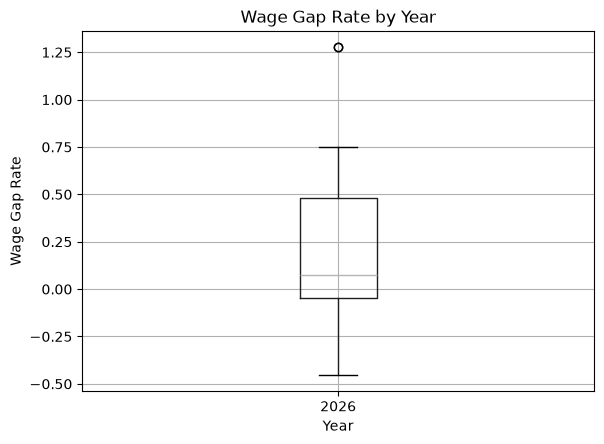

In [81]:
application_df.boxplot(
    column="wage_gap_rate",
    by="application_year"
)

plt.title(
    "Wage Gap Rate by Year"
)

plt.suptitle("")

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Wage Gap Rate"
)

plt.show()

## 12. スキルギャップの年次比較
求人の要求スキルレベルと、候補者の同職種における経験スキルレベルとの差を確認する。

`skill_gap` は、
`候補者スキルレベル - 求人要求スキルレベル`
で算出している。

- 0以上：要求スキルを満たしている
- -1：要求スキルより1段階不足
- -2以下：より大きなスキル不足

2026年に分布がマイナス方向へ移動している場合、スキルミスマッチが拡大している可能性がある。

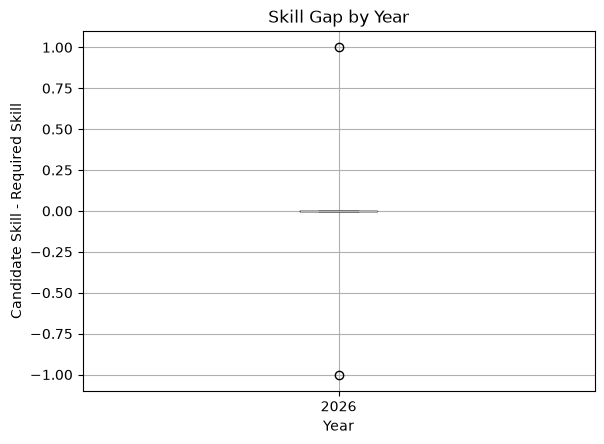

In [66]:
application_df.boxplot(
    column="skill_gap",
    by="application_year"
)

plt.title(
    "Skill Gap by Year"
)

plt.suptitle("")

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Candidate Skill - Required Skill"
)

plt.show()

## 13. 応募意思確認から推薦までの日数の年次比較
応募意思を確認してから企業推薦までに要した日数を比較する。

`intent_to_recommend_days` が長いほど、応募意思確認後の推薦プロセスに時間を要していることを示す。

2026年に分布が長期化している場合、選考プロセスの遅延が発生している可能性がある。

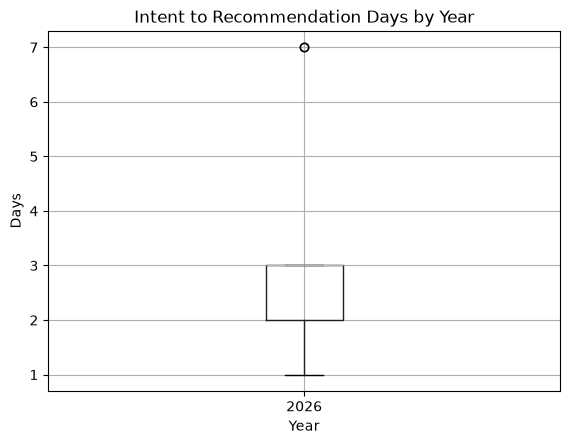

In [67]:
application_df.boxplot(
    column="intent_to_recommend_days",
    by="application_year"
)

plt.title(
    "Intent to Recommendation Days by Year"
)

plt.suptitle("")

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Days"
)

plt.show()

## 14. 就業決定率の年次比較

応募案件のうち、最終的に就業決定へ至った割合を2025年と2026年で比較する。

就業決定率は、給与条件、スキル適合度、選考リードタイムなど複数要因の影響を受けた最終結果の一つとして確認する。

現在は小規模テストデータのため、差そのものではなく方向性を確認する。

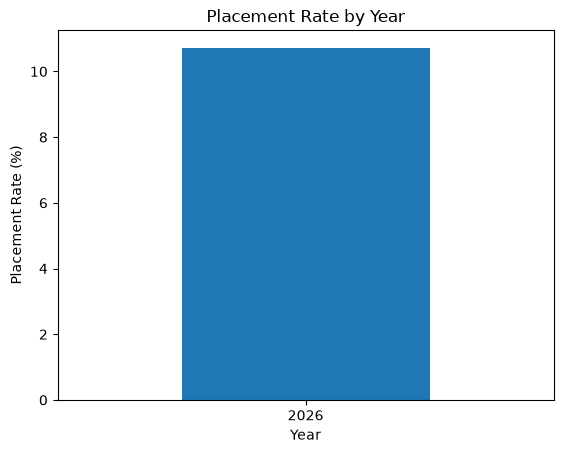

In [69]:
placement_rate_plot = (
    application_year_summary[
        "placement_rate"
    ]
    * 100
)

placement_rate_plot.plot(
    kind="bar"
)

plt.title(
    "Placement Rate by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Placement Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.show()

## 15. EDA所感

### 15.1 データ品質
- SQLiteから `mart_job_analysis` と `mart_application_analysis` の2つの分析マートを正常に読み込めた。
- データ型、欠損値、数値分布を確認した。
- 推薦日、辞退日、就業決定日などの欠損は、業務プロセス上発生し得るNULLとして確認した。
- データ品質チェックSQLでも、ID重複、募集枠超過、日付前後関係などの重大な不整合は確認されなかった。

したがって、テーブル間の基本的な整合性については、
EDAを継続できる状態であることを確認した。

### 15.2 EDAで確認された主な事象
2025年・2026年について、以下の指標を比較した。

- 60日以内募集枠充足率
- 給与ギャップ
- スキルギャップ
- 応募意思確認から推薦までの日数
- 就業決定率

その結果、60日以内募集枠充足率は2025年が0%、2026年が約13%となった。
これは、当初想定していた「2026年に求人充足率が低下する」という方向性とは逆である。
上流指標を確認すると、2025年公開求人の求人エントリー数が0件、2026年が29件となっており、応募案件数にも大きな差が生じていた。

このため、現時点の充足率差は事業要因の差というよりも、
小規模テストデータの生成条件による影響を強く受けていると判断した。

### 15.3 原因調査と修正方針

#### 候補者登録時期
候補者登録年は2025年5名、2026年5名であり、年単位では偏りは確認されなかった。

一方で、2025年4〜9月の求人公開期間に登録済みだった候補者は実質1名であった。

このため、候補者登録日を完全ランダムに生成したことで、
小規模データでは求人公開期間と候補者供給時期が大きくずれていた。

本番データ生成では、
候補者登録数を月単位で一定程度コントロールし、
2025年・2026年の双方で分析対象期間中に十分な候補者が存在する状態とする。

#### 求人公開期間
2025年公開求人に対して、
2026年にCA紹介経由で応募意思確認された案件が6件確認された。

確認したところ、
全求人の `close_date` がNULLであり、
2025年求人が2026年にも紹介対象として残っていた。

実際の業務では長期募集の求人も存在するため、
すべての求人を一律に短期間でクローズすることはしない。

本番データでは、
多くの求人を公開後3〜6か月程度でクローズさせる一方、
一部については長期募集求人としてOPEN状態を維持する。

求人紹介時には、
紹介日時点で公開中の求人のみを候補とする。

#### 応募経路
求人サイトからの自発エントリーだけでなく、
登録候補者にCAが直接アプローチし、
求人紹介から応募へ進む経路も実際の業務上発生し得る。

そのため、
- `self_entry`
- `ca_introduction`
の2つの応募経路は維持する。

求人エントリーが存在しなくてもCA紹介応募が発生すること自体は、
データ異常とは扱わない。

#### 年次集計の基準
指標によって基準とする年を区別する。
応募数、推薦率、辞退率、選考リードタイムなどの応募関連KPIは、
`intent_confirmed_date` を基準とした応募年で集計する。

一方、60日以内募集枠充足率は、
求人公開後60日以内の決定状況を評価する指標であるため、
`open_date` を基準とした求人公開年で集計する。

### 15.4 次のステップ
小規模テストデータについて、残りのEDA結果も確認し、
以下の観点で追加修正の必要性を判断する。

- 給与ギャップが2025年・2026年で想定した方向に変化しているか
- スキルギャップが2026年に悪化する方向となっているか
- 選考リードタイムが2026年に長期化しているか
- 特定の職種やカテゴリへ過度な偏りがないか
- 給与、スキル、選考速度と就業決定の関係が過度に決定論的になっていないか

すべての確認後に合成データ生成ロジックを修正し、
再度小規模データで動作確認を行う。

年次比較および各仮説の方向性に大きな問題がないことを確認した後、
本番規模の合成データを生成し、
統計的仮説検証へ進む。